In [10]:
%%writefile Rebalancing_Logic.py

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------------
# ASSUMED SCENARIO PARAMETERS
# These values are NOT provided by the UCI dataset or project guide.
# ---------------------------------------------------------------------------

REVENUE_PER_RIDE = 3.50
HOLDING_COST_PER_BIKE = 0.75
REBALANCE_TRUCK_COST = 45.00
BIKES_PER_TRUCK_RUN = 150


def recommended_fleet(predicted_demand: pd.Series, safety_margin: float) -> pd.Series:
    """Convert model predictions into recommended fleet stock."""

    return np.ceil(
        predicted_demand * (1 + safety_margin)
    )


def classify_decision(
    stocked: pd.Series,
    actual_demand: pd.Series
) -> np.ndarray:
    """Classify each hour as UNDERSTOCK, OVERSTOCK, or OK."""

    diff = stocked - actual_demand

    return np.select(
        [
            diff < 0,
            diff > 0
        ],
        [
            "UNDERSTOCK",
            "OVERSTOCK"
        ],
        default="OK"
    )


def financial_impact(
    stocked: pd.Series,
    actual_demand: pd.Series
) -> pd.DataFrame:
    """Calculate lost rides, idle bikes, and their modeled costs."""

    lost_rides = np.clip(
        actual_demand - stocked,
        a_min=0,
        a_max=None
    )

    idle_bikes = np.clip(
        stocked - actual_demand,
        a_min=0,
        a_max=None
    )

    return pd.DataFrame({
        "lost_rides": lost_rides,
        "idle_bikes": idle_bikes,
        "lost_revenue": (
            lost_rides * REVENUE_PER_RIDE
        ),
        "holding_cost": (
            idle_bikes * HOLDING_COST_PER_BIKE
        )
    })


def daily_truck_cost(
    df_with_decision: pd.DataFrame
) -> pd.DataFrame:
    """
    Calculate daily truck-run cost based on
    additional bikes created by the safety margin.
    """

    added_bikes = (
        df_with_decision["recommended_fleet"]
        - df_with_decision["predicted_cnt"]
    ).clip(lower=0)

    daily = added_bikes.groupby(
        df_with_decision["dteday"]
    ).sum()

    trucks = np.ceil(
        daily / BIKES_PER_TRUCK_RUN
    )

    cost = (
        trucks * REBALANCE_TRUCK_COST
    ).rename("daily_truck_cost")

    return cost.reset_index()


def generate_decision_metrics(
    df: pd.DataFrame,
    safety_margin: float
) -> pd.DataFrame:
    """
    Full AE pipeline:

    model predictions
        -> safety margin
        -> recommended fleet
        -> operational decision
        -> financial impact

    Required columns:
    dteday
    actual_cnt
    predicted_cnt
    """

    out = df.copy()

    out["safety_margin"] = safety_margin

    out["recommended_fleet"] = recommended_fleet(
        out["predicted_cnt"],
        safety_margin
    )

    out["decision"] = classify_decision(
        out["recommended_fleet"],
        out["actual_cnt"]
    )

    impact = financial_impact(
        out["recommended_fleet"],
        out["actual_cnt"]
    )

    out = pd.concat(
        [
            out.reset_index(drop=True),
            impact.reset_index(drop=True)
        ],
        axis=1
    )

    out["net_operational_cost"] = (
        out["lost_revenue"]
        + out["holding_cost"]
    )

    trucks = daily_truck_cost(out)

    out = out.merge(
        trucks,
        on="dteday",
        how="left"
    )

    return out


def cost_matrix(
    decision_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Confusion-cost-style summary adapted for
    the regression/business decision problem.

    Summarizes UNDERSTOCK, OVERSTOCK and OK decisions.
    """

    summary = decision_df.groupby(
        "decision"
    ).agg(
        hours=("decision", "size"),
        total_lost_rides=("lost_rides", "sum"),
        total_idle_bikes=("idle_bikes", "sum"),
        total_lost_revenue=("lost_revenue", "sum"),
        total_holding_cost=("holding_cost", "sum")
    ).reset_index()

    summary["pct_of_hours"] = (
        summary["hours"]
        / len(decision_df)
        * 100
    ).round(1)

    return summary


def tune_safety_margin(
    df: pd.DataFrame,
    margins=None
) -> pd.DataFrame:
    """
    Test different safety margins and calculate
    the modeled total cost for each margin.

    The tuning table is displayed in
    Metrics_Analysis.ipynb and is not saved
    as a separate CSV.
    """

    if margins is None:

        margins = np.round(
            np.arange(
                0.0,
                0.41,
                0.05
            ),
            2
        )

    rows = []

    for m in margins:

        metrics = generate_decision_metrics(
            df,
            m
        )

        total_truck_cost = (
            metrics
            .drop_duplicates("dteday")
            ["daily_truck_cost"]
            .sum()
        )

        rows.append({

            "safety_margin": m,

            "understock_hours": int(
                (
                    metrics["decision"]
                    == "UNDERSTOCK"
                ).sum()
            ),

            "overstock_hours": int(
                (
                    metrics["decision"]
                    == "OVERSTOCK"
                ).sum()
            ),

            "ok_hours": int(
                (
                    metrics["decision"]
                    == "OK"
                ).sum()
            ),

            "total_lost_revenue": round(
                metrics["lost_revenue"].sum(),
                2
            ),

            "total_holding_cost": round(
                metrics["holding_cost"].sum(),
                2
            ),

            "total_truck_cost": round(
                total_truck_cost,
                2
            ),

            "total_net_cost": round(
                metrics["net_operational_cost"].sum()
                + total_truck_cost,
                2
            )
        })

    return (
        pd.DataFrame(rows)
        .sort_values("total_net_cost")
        .reset_index(drop=True)
    )

Overwriting Rebalancing_Logic.py


In [11]:
#  Setup and Business Assumptions

import pandas as pd
import matplotlib.pyplot as plt

from Rebalancing_Logic import (
    generate_decision_metrics,
    tune_safety_margin,
    cost_matrix,
    REVENUE_PER_RIDE,
    HOLDING_COST_PER_BIKE,
    REBALANCE_TRUCK_COST,
    BIKES_PER_TRUCK_RUN,
)

print("ASSUMED business parameters")
print("(These values are scenario assumptions, not provided by the UCI dataset or project guide.)")
print()
print(f"Revenue per ride:              ${REVENUE_PER_RIDE}")
print(f"Holding cost per idle bike/hr: ${HOLDING_COST_PER_BIKE}")
print(f"Truck dispatch cost:           ${REBALANCE_TRUCK_COST}")
print(f"Truck capacity:                {BIKES_PER_TRUCK_RUN} bikes/run")

ASSUMED business parameters
(These values are scenario assumptions, not provided by the UCI dataset or project guide.)

Revenue per ride:              $3.5
Holding cost per idle bike/hr: $0.75
Truck dispatch cost:           $45.0
Truck capacity:                150 bikes/run


In [12]:
#  Load Chronological Holdout Predictions

import pandas as pd
import urllib.request

# Download holdout predictions from GitHub
url = "https://raw.githubusercontent.com/greshmaarajesh/ML-Final-Lab-Group-11/refs/heads/main/data/Holdout_Predictions.csv"
urllib.request.urlretrieve(url, "holdout_predictions.csv")

# Load the downloaded file
holdout = pd.read_csv("holdout_predictions.csv")
holdout["dteday"] = pd.to_datetime(holdout["dteday"])

print(f"Held-out hours: {len(holdout)}")
print(f"Period: {holdout['dteday'].min().date()} to {holdout['dteday'].max().date()}")

print("\nPrediction data:")
display(holdout.head())

Held-out hours: 3476
Period: 2012-08-07 to 2012-12-31

Prediction data:


,dteday,hr,season,weathersit,actual_cnt,predicted_cnt
0,2012-08-07,12,3,2,283.0,275.392658
1,2012-08-07,13,3,2,253.0,274.637695
2,2012-08-07,14,3,2,261.0,272.293071
3,2012-08-07,15,3,1,306.0,269.368533
4,2012-08-07,16,3,3,445.0,316.455363


In [13]:
#  Decision Threshold Tuning

tuning_sheet = tune_safety_margin(holdout)

best_margin = float(
    tuning_sheet.iloc[0]["safety_margin"]
)

zero_cost = tuning_sheet.loc[
    tuning_sheet["safety_margin"] == 0,
    "total_net_cost"
].values[0]

savings = (
    zero_cost
    - tuning_sheet.iloc[0]["total_net_cost"]
)

print(f"Lowest-cost tested safety margin: {best_margin:.0%}")
print(
    f"Total net cost at {best_margin:.0%} margin: "
    f"${tuning_sheet.iloc[0]['total_net_cost']:,.2f}"
)
print(
    f"Total net cost at 0% margin: "
    f"${zero_cost:,.2f}"
)
print(
    f"Modeled cost difference: "
    f"${savings:,.2f}"
)

print("\nDecision Threshold Tuning Sheet:")
display(tuning_sheet)

print(
    f"\nThe lowest modeled cost occurred at {best_margin:.0%} "
    "among the tested 0%–40% safety margins."
)

Lowest-cost tested safety margin: 35%
Total net cost at 35% margin: $358,217.50
Total net cost at 0% margin: $612,332.25
Modeled cost difference: $254,114.75

Decision Threshold Tuning Sheet:


,safety_margin,understock_hours,overstock_hours,ok_hours,total_lost_revenue,total_holding_cost,total_truck_cost,total_net_cost
0,0.35,1016,2437,23,156362.5,121935.00,79920.0,358217.50
1,0.30,1198,2247,31,188314.0,101552.25,69345.0,359211.25
2,0.40,876,2575,25,130413.5,143637.00,91035.0,365085.50
3,0.25,1393,2057,26,227738.0,82761.75,58365.0,368864.75
4,0.20,1592,1851,33,275887.5,65814.75,47610.0,389312.25
5,0.15,1813,1628,35,333868.5,51002.25,36495.0,421365.75
6,0.10,2077,1369,30,405216.0,39027.00,25515.0,469758.00
7,0.05,2321,1130,25,488411.0,29627.25,15075.0,533113.25
8,0.00,2525,919,32,583075.5,22641.75,6615.0,612332.25



The lowest modeled cost occurred at 35% among the tested 0%–40% safety margins.


Safety margin applied: 35%

Cost Matrix / Decision Summary:


,decision,hours,total_lost_rides,total_idle_bikes,total_lost_revenue,total_holding_cost,pct_of_hours
0,OK,23,0.0,0.0,0.0,0.0,0.7
1,OVERSTOCK,2437,0.0,162580.0,0.0,121935.0,70.1
2,UNDERSTOCK,1016,44675.0,0.0,156362.5,0.0,29.2


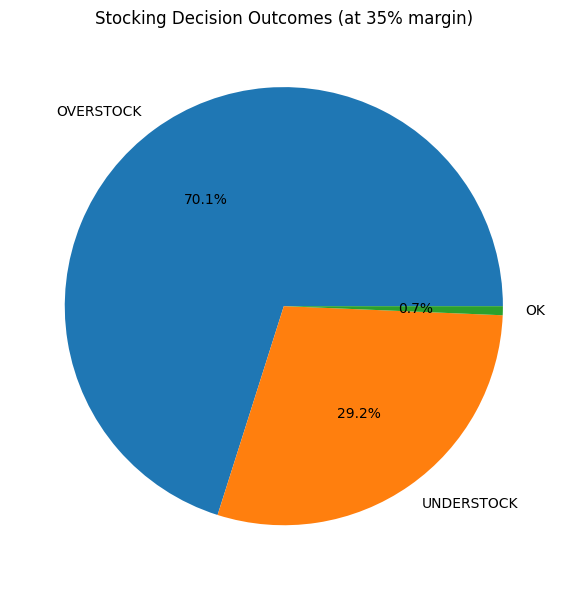

In [14]:
#  Cost Matrix and Decision Summary

metrics = generate_decision_metrics(
    holdout,
    safety_margin=best_margin
)

print(f"Safety margin applied: {best_margin:.0%}")

print("\nCost Matrix / Decision Summary:")
display(cost_matrix(metrics))

decision_counts = metrics["decision"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    decision_counts.values,
    labels=decision_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    f"Stocking Decision Outcomes "
    f"(at {best_margin:.0%} margin)"
)

plt.tight_layout()
plt.show()

Net operational cost by season:


,net_operational_cost
Fall,178949.00
Summer,81328.25
Winter,18020.25


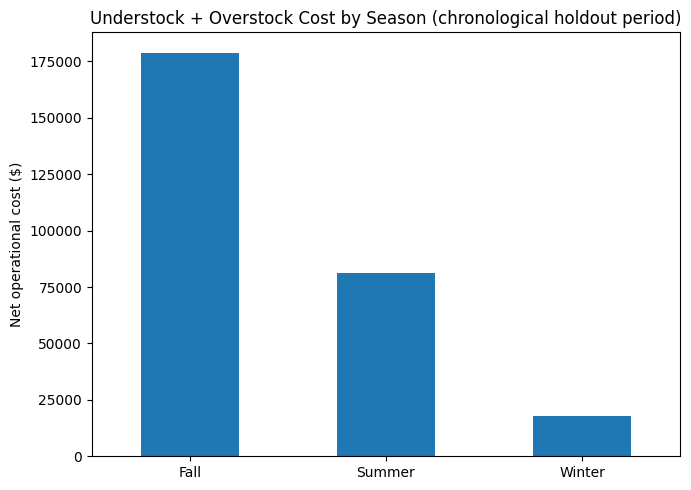

In [15]:
#  Seasonal Decision Analysis

season_labels = {
    1: "Winter",
    2: "Spring",
    3: "Summer",
    4: "Fall"
}

by_season = (
    metrics
    .groupby("season")["net_operational_cost"]
    .sum()
)

by_season.index = [
    season_labels[s]
    for s in by_season.index
]

by_season = by_season.sort_values(
    ascending=False
)

print("Net operational cost by season:")
display(by_season)

plt.figure(figsize=(7, 5))

by_season.plot(kind="bar")

plt.ylabel("Net operational cost ($)")
plt.title(
    "Understock + Overstock Cost by Season "
    "(chronological holdout period)"
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

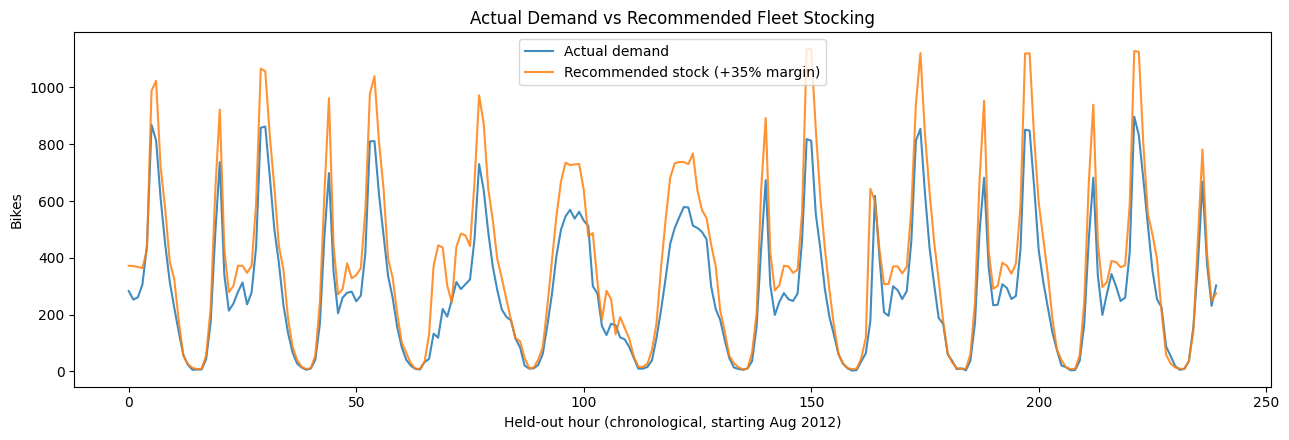

In [16]:
#  Actual vs. Recommended fleet

sample = (
    metrics
    .sort_values(["dteday", "hr"])
    .head(240)
)

plt.figure(figsize=(13, 4.5))

plt.plot(
    range(len(sample)),
    sample["actual_cnt"],
    label="Actual demand",
    alpha=0.85
)

plt.plot(
    range(len(sample)),
    sample["recommended_fleet"],
    label=f"Recommended stock (+{best_margin:.0%} margin)",
    alpha=0.85
)

plt.xlabel(
    "Held-out hour (chronological, starting Aug 2012)"
)

plt.ylabel("Bikes")

plt.title(
    "Actual Demand vs Recommended Fleet Stocking"
)

plt.legend()
plt.tight_layout()
plt.show()

In [17]:
#  Save Decision Metrics

metrics.to_csv(
    "Decision_Metrics.csv",
    index=False
)

print(
    f"Saved Decision_Metrics.csv "
    f"({len(metrics)} rows)"
)

print(
    "This is the row-level AE output used for "
    "business analysis and the BI/dashboard role."
)

Saved Decision_Metrics.csv (3476 rows)
This is the row-level AE output used for business analysis and the BI/dashboard role.
